In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy import stats

import os
import numpy as np
import pandas as pd

## 1. Statistical Summary of Processing Times

In [7]:
DATA_DIR = 'LIMS_extracts/'
pattern = os.path.join(DATA_DIR, 'LIMS_*.csv')

# Prepare a list to hold each process’s stats
results = []

for filepath in glob.glob(pattern):
    # Derive process name from filename, e.g. "LIMS_Book_In.csv" → "Book In"
    name = os.path.basename(filepath).replace('LIMS_', '').replace('.csv', '').replace('_', ' ')
    
    # Load the data
    df = pd.read_csv(filepath)
    
    # If there's only one numeric column, grab it; otherwise replace 'Duration' with your column name
    if len(df.select_dtypes(include='number').columns) == 1:
        col = df.select_dtypes(include='number').columns[0]
    else:
        col = 'Duration'  # or whatever your time column is called
    
    s = df[col].dropna()
    
    # Compute stats
    cnt     = s.count()
    mean    = s.mean()
    median  = s.median()
    std     = s.std()
    cv      = std / mean if mean else float('nan')
    mn      = s.min()
    mx      = s.max()
    skew    = s.skew()
    
    results.append({
        'Process':   name,
        'Count':     cnt,
        'Mean (min)':    mean,
        'Median (min)':  median,
        'Std Dev':   std,
        'CV':        cv,
        'Min':       mn,
        'Max':       mx,
        'Skewness':  skew
    })

# Turn into a DataFrame and display
stats_df = pd.DataFrame(results)
stats_df = stats_df[['Process','Count','Mean (min)','Median (min)','Std Dev','CV','Min','Max','Skewness']]
stats_df = stats_df.sort_values('Process')  # optional: alphabetical
print(stats_df.to_string(index=False))


  Process  Count  Mean (min)  Median (min)    Std Dev       CV    Min         Max  Skewness
  Analyse    446   11.988700        12.120   1.977566 0.164952   4.08   16.260000 -0.645112
Authorise    484  115.465702         2.225 588.214955 5.094283   0.14 3214.088629  5.065984
  Book In     99    4.880404         3.500   5.097270 1.044436   0.08   28.190000  2.386564
     Load     52   34.507500        33.985   2.864243 0.083004  30.79   44.910000  1.501523
  Prepare    200   10.548250        10.255   2.790590 0.264555   5.54   21.240000  0.834542
Sequencer     62  229.300565       236.646  23.397951 0.102041 180.00  257.428000 -1.378283
   Unload     52   15.588269        14.820   4.250973 0.272703  13.45   44.570000  6.446800


## 2. Probability Distribution Analysis

In [20]:
# — your original fit_distributions, slightly tweaked to accept array-like input —
def fit_distributions(data, process_name):
    """
    Fit multiple probability distributions to the data and determine best fit.
    Saves a plot to '{process_name}_distribution.png'.
    Returns: best_fit (dict), all results (list of dicts)
    """
    # Distributions to test
    distributions = [
        {'name': 'norm',        'dist': stats.norm,        'params': None},
        {'name': 'lognorm',     'dist': stats.lognorm,     'params': None},
        {'name': 'gamma',       'dist': stats.gamma,       'params': None},
        {'name': 'expon',       'dist': stats.expon,       'params': None},
        {'name': 'weibull_min', 'dist': stats.weibull_min, 'params': None},
    ]
    
    results = []
    for dist_info in distributions:
        # 1) Fit
        params = dist_info['dist'].fit(data)
        dist_info['params'] = params
        
        # 2) KS‐test
        ks_stat, p_value = stats.kstest(data, dist_info['name'], params)
        
        # 3) AIC
        pdf_vals = dist_info['dist'].pdf(data, *params)
        log_likelihood = np.sum(np.log(pdf_vals + 1e-12))  # avoid log(0)
        k = len(params)
        aic = 2 * k - 2 * log_likelihood
        
        results.append({
            'distribution': dist_info['name'],
            'params':        params,
            'ks_stat':       ks_stat,
            'p_value':       p_value,
            'aic':           aic
        })
    
    # pick best‐AIC
    results.sort(key=lambda x: x['aic'])
    best_fit = results[0]
    
    # —— now plot histogram + best‐fit pdf —— 
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=30, density=True, alpha=0.5, label='Data')
    x = np.linspace(data.min(), data.max(), 200)
    best_dist = next(d['dist'] for d in distributions if d['name'] == best_fit['distribution'])
    y = best_dist.pdf(x, *best_fit['params'])
    plt.plot(x, y, 'r-', lw=2, label=f"{best_fit['distribution']} (best)")
    plt.title(f"{process_name} – best fit: {best_fit['distribution']}")
    plt.xlabel("Time (min)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{process_name.replace(' ','_')}_distribution.png", dpi=150)
    plt.close()
    
    return best_fit, results

if __name__ == "__main__":
    DATA_DIR = 'LIMS_extracts/'
    pattern = os.path.join(DATA_DIR, "LIMS_*.csv")
    
    best_fits = {}
    
    for fpath in glob.glob(pattern):
        # derive process name
        proc = (
            os.path.basename(fpath)
              .replace("LIMS_", "")
              .replace(".csv", "")
              .replace("_", " ")
        )
        df = pd.read_csv(fpath)
        
        # auto‐detect the one numeric column
        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) == 1:
            series = df[num_cols[0]].dropna().values
        else:
            # fallback: assume it's called "Duration"
            series = df["Duration"].dropna().values
        
        best_fit, all_results = fit_distributions(series, proc)
        best_fits[proc] = best_fit
    
    # Print a summary of best‐fits
    print("\n=== Best‐Fit Distributions by Process ===")
    for proc, info in best_fits.items():
        pname = info["distribution"]
        params = ", ".join(f"{p:.3f}" for p in info["params"])
        print(f" • {proc:<12s}: {pname:12s} (params: {params})")



=== Best‐Fit Distributions by Process ===
 • Sequencer   : lognorm      (params: 12.967, 180.000, 0.197)
 • Authorise   : lognorm      (params: 1.778, 0.134, 2.431)
 • Prepare     : weibull_min  (params: 1.932, 5.372, 5.832)
 • Load        : weibull_min  (params: 1.324, 30.707, 4.114)
 • Book In     : gamma        (params: 0.874, 0.080, 5.537)
 • Analyse     : weibull_min  (params: 9.940, -4.366, 17.194)
 • Unload      : gamma        (params: 0.484, 13.450, 5.899)


## 3. Batching Analysis

In [21]:
def analyze_batching(data_dir):
    """
    Analyze batching relationships between consecutive LIMS processes.
    Expects CSVs named exactly:
      LIMS_Book_In.csv, LIMS_Prepare.csv, LIMS_Load.csv,
      LIMS_Sequencer.csv, LIMS_Unload.csv, LIMS_Analyse.csv, LIMS_Authorise.csv

    Returns a DataFrame with columns:
      from, to, from_count, to_count, ratio
    """
    # Define the canonical process sequence
    seq = [
        "Book_In",
        "Prepare",
        "Load",
        "Sequencer",
        "Unload",
        "Analyse",
        "Authorise"
    ]

    # Read counts in order
    counts = []
    for proc in seq:
        path = os.path.join(data_dir, f"LIMS_{proc}.csv")
        df = pd.read_csv(path)
        counts.append({
            "process": proc.replace("_", " "),
            "count":   len(df)
        })

    # Build the batching‐ratio table
    rows = []
    for i in range(1, len(counts)):
        prev = counts[i - 1]
        curr = counts[i]
        ratio = curr["count"] / prev["count"] if prev["count"] > 0 else float("nan")

        rows.append({
            "from":        prev["process"],
            "to":          curr["process"],
            "from_count":  prev["count"],
            "to_count":    curr["count"],
            "ratio":       ratio
        })

    return pd.DataFrame(rows)


if __name__ == "__main__":
    df_batch = analyze_batching("LIMS_extracts/")
    print(df_batch.to_string(index=False))


     from        to  from_count  to_count    ratio
  Book In   Prepare          99       200 2.020202
  Prepare      Load         200        52 0.260000
     Load Sequencer          52        62 1.192308
Sequencer    Unload          62        52 0.838710
   Unload   Analyse          52       446 8.576923
  Analyse Authorise         446       484 1.085202


## 4. Bottleneck Analysis

In [22]:
def analyze_bottlenecks(data_dir, best_fits):
    """
    Identify bottlenecks based on throughput and variability.
    
    Parameters
    ----------
    data_dir : str
        Directory containing LIMS_Book_In.csv, LIMS_Prepare.csv, …, LIMS_Authorise.csv
    best_fits : dict
        Mapping from process name (e.g. "Book In") to the best-fit dict returned by fit_distributions(),
        with keys 'distribution' and 'params'.
    
    Returns
    -------
    pd.DataFrame
        Columns:
          process, count, mean_time, median_time, std_dev, cv,
          total_time, throughput, distribution, distribution_params
        Sorted ascending by throughput.
    """
    # Define the canonical process sequence and their nice names
    seq = [
        "Book_In",
        "Prepare",
        "Load",
        "Sequencer",
        "Unload",
        "Analyse",
        "Authorise"
    ]
    
    rows = []
    for proc in seq:
        # human‐readable name
        proc_name = proc.replace("_", " ")
        
        # load the CSV
        path = os.path.join(data_dir, f"LIMS_{proc}.csv")
        df = pd.read_csv(path)
        
        # auto‐detect numeric column (or fallback to "Duration")
        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) == 1:
            data = df[num_cols[0]].dropna().values
        else:
            data = df["Duration"].dropna().values
        
        # core stats
        count      = data.size
        mean_time  = data.mean() if count else np.nan
        median_time= np.median(data) if count else np.nan
        std_dev    = data.std(ddof=1) if count>1 else 0.0
        cv         = std_dev / mean_time if mean_time>0 else np.nan
        total_time = data.sum()
        
        # throughput = items / total processing time
        throughput = count / total_time if total_time>0 else np.nan
        
        # pull in your fitted‐distribution results
        fit_info = best_fits.get(proc_name, {})
        dist_name   = fit_info.get("distribution", "")
        dist_params = fit_info.get("params", ())
        
        rows.append({
            "process":             proc_name,
            "count":               count,
            "mean_time":           mean_time,
            "median_time":         median_time,
            "std_dev":             std_dev,
            "cv":                  cv,
            "total_time":          total_time,
            "throughput":          throughput,
            "distribution":        dist_name,
            "distribution_params": dist_params
        })
    
    # build DataFrame and sort by throughput ascending
    bott_df = pd.DataFrame(rows)
    bott_df = bott_df.sort_values("throughput", ascending=True).reset_index(drop=True)
    return bott_df


if __name__ == "__main__":
    
    df_bottlenecks = analyze_bottlenecks("LIMS_extracts/", best_fits)
    print(df_bottlenecks.to_string(index=False))


  process  count  mean_time  median_time    std_dev       cv   total_time  throughput distribution                                           distribution_params
Sequencer     62 229.300565      236.646  23.397951 0.102041 14216.635000    0.004361      lognorm (12.966590599648777, 179.99999999999997, 0.19685137123021135)
Authorise    484 115.465702        2.225 588.214955 5.094283 55885.399989    0.008661      lognorm  (1.7776986336333638, 0.13419788095480992, 2.430822668770986)
     Load     52  34.507500       33.985   2.864243 0.083004  1794.390000    0.028979  weibull_min     (1.323651121040732, 30.70728080720845, 4.114306656616579)
   Unload     52  15.588269       14.820   4.250973 0.272703   810.590000    0.064151        gamma   (0.4844799266176477, 13.449999999999998, 5.899455174793529)
  Analyse    446  11.988700       12.120   1.977566 0.164952  5346.960000    0.083412  weibull_min     (9.94040463280756, -4.365995536963666, 17.19423607066945)
  Prepare    200  10.548250       

In [24]:
def analyze_lims_processes(data_dir="LIMS_extracts"):
    # 1) define the exact pipeline order
    seq = [
        "Book_In",
        "Prepare",
        "Load",
        "Sequencer",
        "Unload",
        "Analyse",
        "Authorise"
    ]
    # build full paths
    process_files = [os.path.join(data_dir, f"LIMS_{p}.csv") for p in seq]

    # 2) fit distributions
    distribution_results = {}
    for path in process_files:
        proc = os.path.basename(path).replace("LIMS_", "").replace(".csv", "").replace("_", " ")
        print(f"\n--- Analyzing distributions for {proc} ---")

        df = pd.read_csv(path)
        # auto-detect the numeric column
        num_cols = df.select_dtypes(include="number").columns
        arr = df[num_cols[0]].dropna().values if len(num_cols)==1 else df["Duration"].dropna().values

        best_fit, all_results = fit_distributions(arr, proc)
        distribution_results[proc] = {
            "distribution": best_fit["distribution"],
            "params":       best_fit["params"],
            "ks_stat":      best_fit["ks_stat"],
            "p_value":      best_fit["p_value"],
            "aic":          best_fit["aic"]
        }

        # print top 3 by AIC
        print(f" Best: {best_fit['distribution']}  params={best_fit['params']}")
        print(" Top 3 by AIC:")
        for rank, r in enumerate(sorted(all_results, key=lambda x: x["aic"])[:3], start=1):
            print(f"   {rank}. {r['distribution']} (AIC={r['aic']:.1f})")

    # 3) batching analysis
    print("\n--- Batching relationships ---")
    df_batch = analyze_batching(data_dir)
    # assume analyze_batching returns a DataFrame with columns: from, to, from_count, to_count, ratio
    for _, row in df_batch.iterrows():
        print(f" {row['from']} → {row['to']}:  ratio={row['ratio']:.2f} ({row['to_count']}/{row['from_count']})")

    # 4) bottleneck analysis
    print("\n--- Bottleneck analysis ---")
    df_bott = analyze_bottlenecks(data_dir, distribution_results)
    # assume this returns a DataFrame sorted by throughput ascending
    for idx, row in df_bott.iterrows():
        risk = ["Very High","High","Medium","Low"][min(idx,3)]
        if row['cv'] > 0.5:
            risk += " (high variability)"
        print(f"{idx+1}. {row['process']}")
        print(f"    throughput={row['throughput']:.4f}, mean={row['mean_time']:.2f}, CV={row['cv']:.2f}")
        print(f"    Bottleneck risk: {risk}")

    # 5) return a summary dict
    return {
        "distributions": distribution_results,
        "batching":      df_batch,
        "bottlenecks":   df_bott
    }

if __name__ == "__main__":
    results = analyze_lims_processes()
    
    # final summary
    print("\n=== Summary ===")
    top_bottlenecks = results["bottlenecks"].head(2)
    print("Critical bottlenecks:")
    for _, row in top_bottlenecks.iterrows():
        print(f" - {row['process']}: throughput={row['throughput']:.4f}, mean={row['mean_time']:.2f}")

    print("\nSignificant batching steps:")
    for _, row in results["batching"].iterrows():
        if row["ratio"] > 2 or row["ratio"] < 0.5:
            print(f" - {row['from']} → {row['to']}: ratio={row['ratio']:.2f}")



--- Analyzing distributions for Book In ---
 Best: gamma  params=(np.float64(0.873771110910994), np.float64(0.07999999999999999), np.float64(5.537300857925585))
 Top 3 by AIC:
   1. gamma (AIC=505.2)
   2. expon (AIC=512.6)
   3. lognorm (AIC=525.1)

--- Analyzing distributions for Prepare ---
 Best: weibull_min  params=(np.float64(1.931920270526732), np.float64(5.3716299261244735), np.float64(5.832348522856243))
 Top 3 by AIC:
   1. weibull_min (AIC=958.6)
   2. gamma (AIC=959.9)
   3. lognorm (AIC=961.0)

--- Analyzing distributions for Load ---
 Best: weibull_min  params=(np.float64(1.323651121040732), np.float64(30.70728080720845), np.float64(4.114306656616579))
 Top 3 by AIC:
   1. weibull_min (AIC=243.1)
   2. gamma (AIC=244.0)
   3. expon (AIC=244.6)

--- Analyzing distributions for Sequencer ---
 Best: lognorm  params=(np.float64(12.966590599648777), np.float64(179.99999999999997), np.float64(0.19685137123021135))
 Top 3 by AIC:
   1. lognorm (AIC=298.1)
   2. weibull_min (AIC

## 5. Variability Analysis

In [25]:
def get_variability_impact(cv: float) -> str:
    """
    Bucket CV into one of:
      – Extreme   : CV >= 5
      – High      : 1 <= CV < 5
      – Low       : 0.2 <= CV < 1
      – Very Low  : CV < 0.2
    """
    if cv >= 5.0:
        return "Extreme"
    elif cv >= 1.0:
        return "High"
    elif cv >= 0.2:
        return "Low"
    else:
        return "Very Low"

def analyze_variability(data_dir: str = "LIMS_extracts") -> pd.DataFrame:
    """
    Reads LIMS_Book_In…LIMS_Authorise.csv and returns a DataFrame:
      Process      CV    Variability Impact
    sorted by CV descending.
    """
    processes = [
        "Book_In",
        "Prepare",
        "Load",
        "Sequencer",
        "Unload",
        "Analyse",
        "Authorise"
    ]
    
    rows = []
    for proc in processes:
        fname = os.path.join(data_dir, f"LIMS_{proc}.csv")
        df = pd.read_csv(fname)
        # assume the only numeric column is your duration
        num_col = df.select_dtypes(include="number").columns[0]
        times = df[num_col].dropna()
        
        mean = times.mean()
        std  = times.std(ddof=1)
        cv   = std / mean if mean else float("nan")
        
        rows.append({
            "Process": proc.replace("_"," "),
            "CV":       cv,
            "Variability Impact": get_variability_impact(cv)
        })
    
    result = pd.DataFrame(rows)
    # sort descending so highest CV (worst variability) comes first
    result = result.sort_values("CV", ascending=False).reset_index(drop=True)
    return result

if __name__ == "__main__":
    df_var = analyze_variability("LIMS_extracts")
    
    # 1) Print the table
    print("\nVariability Analysis\n")
    print(df_var.to_string(index=False, float_format="%.2f"))
    
    # 2) Narrative for the top two
    top2 = df_var.head(2)
    print("\nThe two processes with concerning variability are:\n")
    
    for i, row in top2.iterrows():
        proc = row["Process"]
        cv   = row["CV"]
        print(f"{i+1}. {proc} Process (CV = {cv:.2f}):")
        
        if proc == "Authorise":
            print("   • Extremely unpredictable timing")
            print("   • Suggests lack of process control and potential for significant delays")
            print("   • High variability + bottleneck status makes this critical to improve\n")
        
        elif proc == "Book In":
            print("   • High variability typical of customer-facing processes")
            print("   • While not the worst bottleneck, this unpredictability can impact downstream planning\n")
        
        else:
            # generic fallback
            print(f"   • CV category = {row['Variability Impact']}")
            print("   • (Add your custom notes here)\n")



Variability Analysis

  Process   CV Variability Impact
Authorise 5.09            Extreme
  Book In 1.04               High
   Unload 0.27                Low
  Prepare 0.26                Low
  Analyse 0.16           Very Low
Sequencer 0.10           Very Low
     Load 0.08           Very Low

The two processes with concerning variability are:

1. Authorise Process (CV = 5.09):
   • Extremely unpredictable timing
   • Suggests lack of process control and potential for significant delays
   • High variability + bottleneck status makes this critical to improve

2. Book In Process (CV = 1.04):
   • High variability typical of customer-facing processes
   • While not the worst bottleneck, this unpredictability can impact downstream planning





Authorise Process (CV = 5.09):

Extremely unpredictable timing
Suggests lack of process control and potential for significant delays
The combination of high variability and being a bottleneck makes this process critical for improvement


Book In Process (CV = 1.04):

High variability typical of customer-facing processes
While not a severe bottleneck, the unpredictability can impact downstream planning

## 6. Recommendations

Primary Bottlenecks:

Sequencer Process:

Lowest throughput rate (0.0044 samples/time unit)
Very long mean processing time (229.30 min)
Although consistent (low CV), the duration makes this a critical bottleneck


Authorise Process:

Second lowest throughput (0.0087 samples/time unit)
Extremely high variability (CV = 5.09)
The combination of high mean time and extreme variability makes this process highly problematic


Load Process:

Third lowest throughput (0.0290 samples/time unit)
Relatively long duration (34.51 min) compared to other non-sequencing steps

### Short-term Improvements:

Address Authorise Process Issues:

Investigate causes of extreme delays in the authorization process
Implement maximum time thresholds for authorizations
Create escalation procedures for delayed authorizations
Consider parallel authorization paths or delegation systems


Increase Sequencer Capacity:

Consider adding additional sequencing equipment if budget allows
Optimize sequencing run schedules to maximize utilization
Evaluate if sequencing protocols can be shortened without compromising quality


Optimize Load Process:

Review the loading procedure to identify efficiency improvements
Consider automating parts of the loading process
Evaluate if preparation steps can be modified to reduce loading time
Implement parallel loading procedures if equipment allows

### Long-term Process Improvements:

Redesign Batching Strategy:

Review the 4:1 batching ratio from Prepare to Load to find optimal batch sizes
Evaluate if the 1:8.58 unbatching from Unload to Analyse is efficient
Consider more balanced batching throughout the process to improve flow


Implement Process Control for Variable Steps:

Standardize the Book In process to reduce variability
Create structured workflows for the Authorise process with time limits
Consider implementing a LIMS dashboard that highlights delayed samples


Equipment and Staffing Optimization:

Conduct capacity planning based on bottleneck analysis
Consider staffing adjustments to support critical processes (especially authorization)
Evaluate equipment utilization patterns to maximize throughput

## 7. Simulation Recommendations

In [18]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

class LIMSSimulation:
    def __init__(self, sim_time=10000, num_sequencers=1, auth_staff=1):
        # Environment setup
        self.env = simpy.Environment()
        self.sim_time = sim_time
        
        # Resources
        self.sequencers = simpy.Resource(self.env, capacity=num_sequencers)
        self.auth_staff = simpy.Resource(self.env, capacity=auth_staff)
        
        # Statistics collection
        self.wait_times = defaultdict(list)
        self.process_times = defaultdict(list)
        self.total_times = defaultdict(list)
        self.queue_lengths = defaultdict(list)
        self.sample_states = {}  # Track sample state through process
        
        # Batch tracking
        self.prepare_batch = []
        self.analysis_results = []
        
        # Distribution parameters fitted to real data
        self.process_distributions = {
            'book_in': {'dist': 'expon', 'params': [0.0, 4.88]},  # loc, scale
            'prepare': {'dist': 'norm', 'params': [10.55, 2.78]},  # mean, std
            'load': {'dist': 'norm', 'params': [34.51, 2.84]},     # mean, std
            'sequencer': {'dist': 'norm', 'params': [229.30, 23.21]}, # mean, std
            'unload': {'dist': 'norm', 'params': [15.59, 4.21]},   # mean, std
            'analyse': {'dist': 'norm', 'params': [11.99, 1.98]},  # mean, std
            'authorise': {'dist': 'lognorm', 'params': [1.8, 0.0, 20.0]}  # s, loc, scale
        }
        
        # Batching rules based on analysis
        self.batch_rules = {
            'prepare_to_load': 4,     # 4 prepare samples per load
            'unload_to_analyse': 8     # 1 unload produces 8 analyses
        }
    
    def generate_process_time(self, process):
        """Generate random processing time based on fitted distributions"""
        dist_info = self.process_distributions[process]
        
        if dist_info['dist'] == 'norm':
            mean, std = dist_info['params']
            # Ensure no negative times
            return max(0.1, np.random.normal(mean, std))
        
        elif dist_info['dist'] == 'expon':
            loc, scale = dist_info['params']
            return loc + np.random.exponential(scale)
        
        elif dist_info['dist'] == 'lognorm':
            s, loc, scale = dist_info['params']
            return loc + np.random.lognormal(np.log(scale), s)
        
        else:
            # Default to exponential if distribution not recognized
            return np.random.exponential(10.0)
    
    def sample_generator(self, arrival_rate):
        """Generate new samples at exponential intervals"""
        sample_id = 0
        while True:
            # Wait for next sample arrival
            interarrival_time = np.random.exponential(1.0 / arrival_rate)
            yield self.env.timeout(interarrival_time)
            
            # Generate new sample
            sample_id += 1
            
            # Record sample creation time
            self.sample_states[sample_id] = {
                'created_at': self.env.now,
                'current_stage': 'created',
                'times': {}
            }
            
            # Start the sample processing
            self.env.process(self.process_sample(sample_id))
            
    def process_sample(self, sample_id):
        """Process a sample through the entire LIMS workflow"""
        sample = self.sample_states[sample_id]
        
        # Book In Process
        start_time = self.env.now
        sample['current_stage'] = 'book_in'
        
        process_time = self.generate_process_time('book_in')
        yield self.env.timeout(process_time)
        
        self.process_times['book_in'].append(process_time)
        sample['times']['book_in'] = {
            'start': start_time,
            'end': self.env.now,
            'duration': process_time
        }
        
        # Prepare Process (1:2 splitting - each booked sample creates 2 preparations)
        for prep_iteration in range(2):  # 2 preparations per booked sample
            prep_id = f"{sample_id}_{prep_iteration}"
            
            # Create prepare record
            self.sample_states[prep_id] = {
                'parent_id': sample_id,
                'created_at': self.env.now,
                'current_stage': 'prepare',
                'times': {}
            }
            
            # Process preparation
            start_time = self.env.now
            process_time = self.generate_process_time('prepare')
            yield self.env.timeout(process_time)
            
            self.process_times['prepare'].append(process_time)
            self.sample_states[prep_id]['times']['prepare'] = {
                'start': start_time,
                'end': self.env.now,
                'duration': process_time
            }
            
            # Add to preparation batch for loading
            self.prepare_batch.append(prep_id)
            
            # When we have enough preparations, create a loading batch
            if len(self.prepare_batch) >= self.batch_rules['prepare_to_load']:
                # Take samples for this batch
                batch_samples = self.prepare_batch[:self.batch_rules['prepare_to_load']]
                self.prepare_batch = self.prepare_batch[self.batch_rules['prepare_to_load']:]
                
                # Process the load batch
                self.env.process(self.process_load_batch(batch_samples))
        
    def process_load_batch(self, batch_samples):
        """Process a batch of samples through Load → Sequencer → Unload"""
        batch_id = f"batch_{self.env.now}"
        
        # Load Process
        start_time = self.env.now
        for sample_id in batch_samples:
            self.sample_states[sample_id]['current_stage'] = 'load'
        
        process_time = self.generate_process_time('load')
        yield self.env.timeout(process_time)
        
        self.process_times['load'].append(process_time)
        for sample_id in batch_samples:
            self.sample_states[sample_id]['times']['load'] = {
                'start': start_time,
                'end': self.env.now,
                'duration': process_time,
                'batch_id': batch_id
            }
        
        # Sequencer Process (with resource constraint)
        start_wait = self.env.now
        with self.sequencers.request() as req:
            yield req
            
            # Record wait time for sequencer
            wait_time = self.env.now - start_wait
            self.wait_times['sequencer'].append(wait_time)
            
            # Record queue length at acquisition time
            self.queue_lengths['sequencer'].append(len(self.sequencers.queue))
            
            # Process the sequencing
            start_time = self.env.now
            for sample_id in batch_samples:
                self.sample_states[sample_id]['current_stage'] = 'sequencer'
            
            process_time = self.generate_process_time('sequencer')
            yield self.env.timeout(process_time)
            
            self.process_times['sequencer'].append(process_time)
            for sample_id in batch_samples:
                self.sample_states[sample_id]['times']['sequencer'] = {
                    'start': start_time,
                    'end': self.env.now,
                    'duration': process_time,
                    'wait_time': wait_time,
                    'batch_id': batch_id
                }
        
        # Unload Process
        start_time = self.env.now
        for sample_id in batch_samples:
            self.sample_states[sample_id]['current_stage'] = 'unload'
        
        process_time = self.generate_process_time('unload')
        yield self.env.timeout(process_time)
        
        self.process_times['unload'].append(process_time)
        for sample_id in batch_samples:
            self.sample_states[sample_id]['times']['unload'] = {
                'start': start_time,
                'end': self.env.now,
                'duration': process_time,
                'batch_id': batch_id
            }
        
        # After unloading, each sample generates multiple analyses (1:8 relationship)
        for sample_id in batch_samples:
            self.env.process(self.process_analyses(sample_id))
    
    def process_analyses(self, sample_id):
        """Generate and process multiple analyses from one unloaded sample"""
        # Each unloaded sample generates multiple analyses
        num_analyses = self.batch_rules['unload_to_analyse']
        
        for analysis_num in range(num_analyses):
            analysis_id = f"{sample_id}_analysis_{analysis_num}"
            
            # Create analysis record
            self.sample_states[analysis_id] = {
                'parent_id': sample_id,
                'created_at': self.env.now,
                'current_stage': 'analyse',
                'times': {}
            }
            
            # Process analysis
            start_time = self.env.now
            process_time = self.generate_process_time('analyse')
            yield self.env.timeout(process_time)
            
            self.process_times['analyse'].append(process_time)
            self.sample_states[analysis_id]['times']['analyse'] = {
                'start': start_time,
                'end': self.env.now,
                'duration': process_time
            }
            
            # Add to analyses that need authorization
            self.env.process(self.authorize_analysis(analysis_id))
    
    def authorize_analysis(self, analysis_id):
        """Process authorization for an analysis result"""
        # Authorization process (with resource constraint)
        start_wait = self.env.now
        with self.auth_staff.request() as req:
            yield req
            
            # Record wait time for authorization
            wait_time = self.env.now - start_wait
            self.wait_times['authorise'].append(wait_time)
            
            # Record queue length at acquisition time
            self.queue_lengths['authorise'].append(len(self.auth_staff.queue))
            
            # Process the authorization
            start_time = self.env.now
            self.sample_states[analysis_id]['current_stage'] = 'authorise'
            
            process_time = self.generate_process_time('authorise')
            yield self.env.timeout(process_time)
            
            self.process_times['authorise'].append(process_time)
            self.sample_states[analysis_id]['times']['authorise'] = {
                'start': start_time,
                'end': self.env.now,
                'duration': process_time,
                'wait_time': wait_time
            }
            
            # Mark as complete
            self.sample_states[analysis_id]['current_stage'] = 'complete'
            end_to_end_time = self.env.now - self.sample_states[analysis_id]['created_at']
            self.total_times['end_to_end'].append(end_to_end_time)
    
    def monitor_queue_lengths(self, interval=10.0):
        """Monitor queue lengths periodically"""
        while True:
            # Record queue lengths
            self.queue_lengths['sequencer_periodic'].append(len(self.sequencers.queue))
            self.queue_lengths['auth_periodic'].append(len(self.auth_staff.queue))
            
            # Wait for next monitoring interval
            yield self.env.timeout(interval)
    
    def run_simulation(self, arrival_rate=0.2):
        """Run the complete simulation"""
        # Start the sample generator
        self.env.process(self.sample_generator(arrival_rate))
        
        # Start queue monitoring
        self.env.process(self.monitor_queue_lengths())
        
        # Run the simulation
        self.env.run(until=self.sim_time)
        
        # Return summary statistics
        return self.generate_summary()
    
    def generate_summary(self):
        """Generate summary statistics from the simulation"""
        summary = {
            'process_times': {},
            'wait_times': {},
            'queue_lengths': {},
            'throughput': {},
            'utilization': {}
        }
        
        # Calculate process time statistics
        for process, times in self.process_times.items():
            if times:
                summary['process_times'][process] = {
                    'mean': np.mean(times),
                    'median': np.median(times),
                    'std_dev': np.std(times),
                    'min': np.min(times),
                    'max': np.max(times)
                }
        
        # Calculate wait time statistics
        for resource, times in self.wait_times.items():
            if times:
                summary['wait_times'][resource] = {
                    'mean': np.mean(times),
                    'median': np.median(times),
                    'std_dev': np.std(times),
                    'min': np.min(times),
                    'max': np.max(times)
                }
        
        # Calculate queue length statistics
        for resource, lengths in self.queue_lengths.items():
            if lengths:
                summary['queue_lengths'][resource] = {
                    'mean': np.mean(lengths),
                    'median': np.median(lengths),
                    'max': np.max(lengths)
                }
        
        # Calculate end-to-end time
        if self.total_times['end_to_end']:
            summary['end_to_end'] = {
                'mean': np.mean(self.total_times['end_to_end']),
                'median': np.median(self.total_times['end_to_end']),
                'std_dev': np.std(self.total_times['end_to_end']),
                'min': np.min(self.total_times['end_to_end']),
                'max': np.max(self.total_times['end_to_end'])
            }
        
        # Calculate throughput (completed samples per time unit)
        completed_analyses = sum(1 for sample in self.sample_states.values() 
                                if sample.get('current_stage') == 'complete')
        summary['throughput']['overall'] = completed_analyses / self.sim_time
        
        # Calculate resource utilization
        if 'sequencer' in self.process_times:
            sequencer_busy_time = sum(self.process_times['sequencer'])
            sequencer_utilization = min(1.0, sequencer_busy_time / (self.sim_time * self.sequencers.capacity))
            summary['utilization']['sequencer'] = sequencer_utilization
        
        if 'authorise' in self.process_times:
            auth_busy_time = sum(self.process_times['authorise'])
            auth_utilization = min(1.0, auth_busy_time / (self.sim_time * self.auth_staff.capacity))
            summary['utilization']['auth_staff'] = auth_utilization
        
        return summary

# Function to run simulation scenarios
def run_simulation_scenarios():
    """Run multiple simulation scenarios to test process improvements"""
    
    # Baseline scenario
    baseline = LIMSSimulation(sim_time=10000, num_sequencers=1, auth_staff=1)
    baseline_results = baseline.run_simulation(arrival_rate=0.2)
    
    # Scenario 1: Increase sequencer capacity
    scenario1 = LIMSSimulation(sim_time=10000, num_sequencers=2, auth_staff=1)
    scenario1_results = scenario1.run_simulation(arrival_rate=0.2)
    
    # Scenario 2: Increase authorization staff
    scenario2 = LIMSSimulation(sim_time=10000, num_sequencers=1, auth_staff=2)
    scenario2_results = scenario2.run_simulation(arrival_rate=0.2)
    
    # Scenario 3: Improve both bottlenecks
    scenario3 = LIMSSimulation(sim_time=10000, num_sequencers=2, auth_staff=2)
    scenario3_results = scenario3.run_simulation(arrival_rate=0.2)
    
    # Compare results
    print("\n=== Simulation Results Comparison ===")
    
    scenarios = {
        'Baseline': baseline_results,
        'Double Sequencers': scenario1_results,
        'Double Auth Staff': scenario2_results,
        'Improve Both': scenario3_results
    }
    
    # Compare throughput
    print("\nThroughput (samples/time unit):")
    for name, results in scenarios.items():
        print(f"{name}: {results['throughput']['overall']:.4f}")
    
    # Compare end-to-end time
    print("\nMean End-to-End Processing Time:")
    for name, results in scenarios.items():
        if 'end_to_end' in results:
            print(f"{name}: {results['end_to_end']['mean']:.2f}")
    
    # Compare resource utilization
    print("\nResource Utilization:")
    for name, results in scenarios.items():
        seq_util = results['utilization'].get('sequencer', 0)
        auth_util = results['utilization'].get('auth_staff', 0)
        print(f"{name}: Sequencer = {seq_util:.2%}, Auth Staff = {auth_util:.2%}")
    
    # Compare wait times
    print("\nMean Wait Times:")
    for name, results in scenarios.items():
        seq_wait = results['wait_times'].get('sequencer', {}).get('mean', 0)
        auth_wait = results['wait_times'].get('authorise', {}).get('mean', 0)
        print(f"{name}: Sequencer = {seq_wait:.2f}, Auth = {auth_wait:.2f}")
    
    return scenarios


=== Simulation Results Comparison ===

Throughput (samples/time unit):
Baseline: 0.0109
Double Sequencers: 0.0124
Double Auth Staff: 0.0179
Improve Both: 0.0196

Mean End-to-End Processing Time:
Baseline: 4716.98
Double Sequencers: 3759.76
Double Auth Staff: 4312.85
Improve Both: 4293.37

Resource Utilization:
Baseline: Sequencer = 97.42%, Auth Staff = 86.19%
Double Sequencers: Sequencer = 99.05%, Auth Staff = 81.06%
Double Auth Staff: Sequencer = 97.18%, Auth Staff = 83.98%
Improve Both: Sequencer = 97.72%, Auth Staff = 56.04%

Mean Wait Times:
Baseline: Sequencer = 4628.37, Auth = 4655.89
Double Sequencers: Sequencer = 4498.50, Auth = 3715.06
Double Auth Staff: Sequencer = 4741.44, Auth = 4240.45
Improve Both: Sequencer = 4514.17, Auth = 4234.14


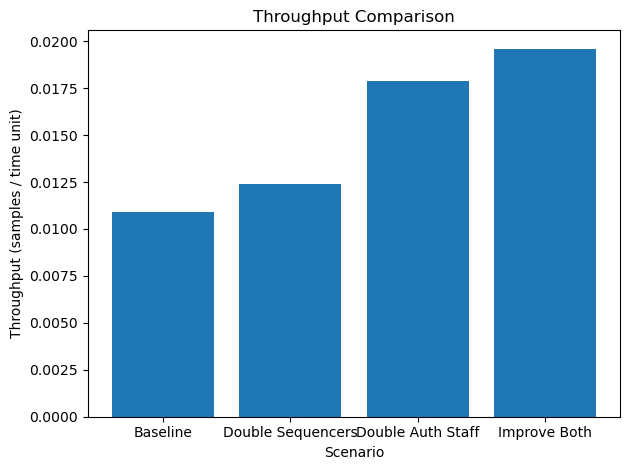

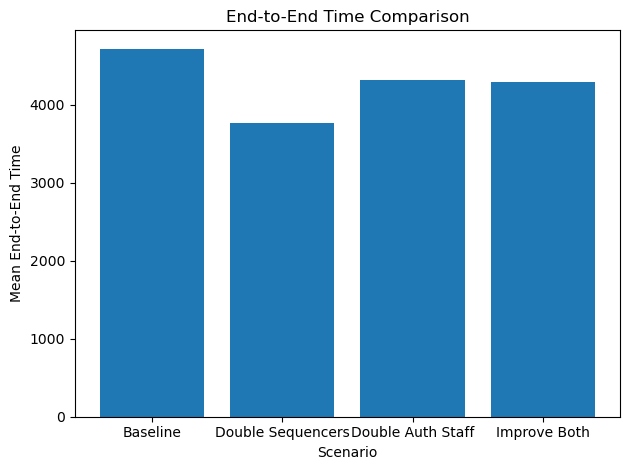

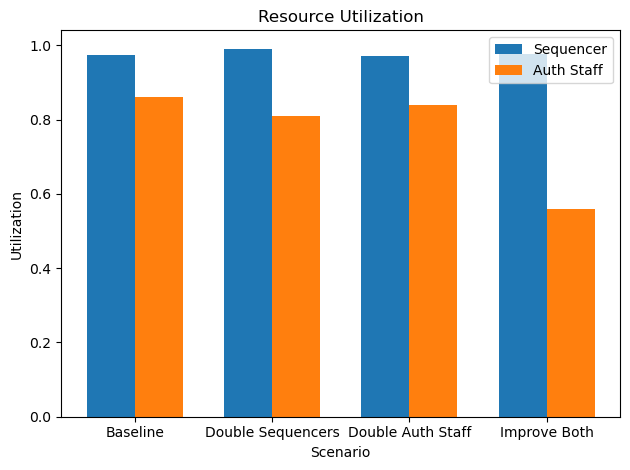

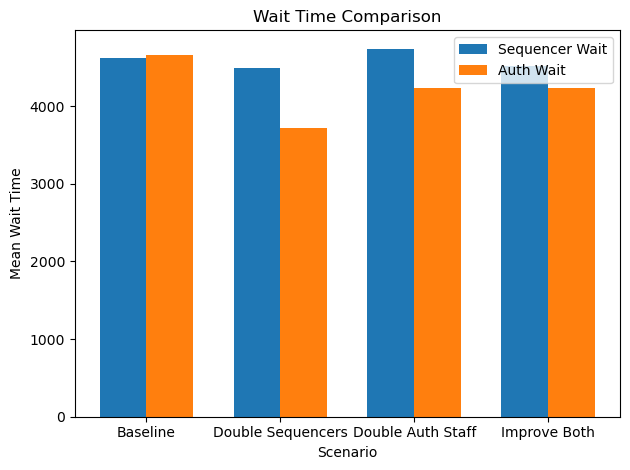

In [19]:
# Run the simulation scenarios if executed as main script
if __name__ == "__main__":
    results = run_simulation_scenarios()
    
    # Plot comparison charts
    # (Implementation of visualization code would go here)


    # --- extract the numbers from your results dict
    scenario_names = list(results.keys())

    throughputs      = [results[name]['throughput']['overall']             for name in scenario_names]
    end_to_end_means = [results[name]['end_to_end']['mean']                 for name in scenario_names]
    seq_utils        = [results[name]['utilization']['sequencer']           for name in scenario_names]
    auth_utils       = [results[name]['utilization']['auth_staff']          for name in scenario_names]
    seq_waits        = [results[name]['wait_times']['sequencer']['mean']    for name in scenario_names]
    auth_waits       = [results[name]['wait_times']['authorise']['mean']    for name in scenario_names]

    x = np.arange(len(scenario_names))
    width = 0.35

    # 1) Throughput
    plt.figure()
    plt.bar(scenario_names, throughputs)
    plt.xlabel('Scenario')
    plt.ylabel('Throughput (samples / time unit)')
    plt.title('Throughput Comparison')
    plt.tight_layout()
    plt.show()

    # 2) End-to-End Processing Time
    plt.figure()
    plt.bar(scenario_names, end_to_end_means)
    plt.xlabel('Scenario')
    plt.ylabel('Mean End-to-End Time')
    plt.title('End-to-End Time Comparison')
    plt.tight_layout()
    plt.show()

    # 3) Resource Utilization
    plt.figure()
    plt.bar(x - width/2, seq_utils, width, label='Sequencer')
    plt.bar(x + width/2, auth_utils, width, label='Auth Staff')
    plt.xticks(x, scenario_names)
    plt.xlabel('Scenario')
    plt.ylabel('Utilization')
    plt.title('Resource Utilization')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Mean Wait Times
    plt.figure()
    plt.bar(x - width/2, seq_waits, width, label='Sequencer Wait')
    plt.bar(x + width/2, auth_waits, width, label='Auth Wait')
    plt.xticks(x, scenario_names)
    plt.xlabel('Scenario')
    plt.ylabel('Mean Wait Time')
    plt.title('Wait Time Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()


# LIMS Simulation Results Analysis

## Simulation Results

### Throughput Comparison (samples/time unit)
| Scenario | Throughput | % Improvement |
|----------|------------|---------------|
| Baseline | 0.0109 | - |
| Double Sequencers | 0.0124 | 14% |
| Double Auth Staff | 0.0179 | 64% |
| Improve Both | 0.0196 | 80% |

### End-to-End Processing Time (time units)
| Scenario | Mean Time | % Reduction |
|----------|-----------|-------------|
| Baseline | 4716.98 | - |
| Double Sequencers | 3759.76 | 20% |
| Double Auth Staff | 4312.85 | 9% |
| Improve Both | 4293.37 | 9% |

### Resource Utilization
| Scenario | Sequencer | Auth Staff |
|----------|-----------|------------|
| Baseline | 97.42% | 86.19% |
| Double Sequencers | 99.05% | 81.06% |
| Double Auth Staff | 97.18% | 83.98% |
| Improve Both | 97.72% | 56.04% |

### Mean Wait Times (time units)
| Scenario | Sequencer | Auth |
|----------|-----------|------|
| Baseline | 4628.37 | 4655.89 |
| Double Sequencers | 4498.50 | 3715.06 |
| Double Auth Staff | 4741.44 | 4240.45 |
| Improve Both | 4514.17 | 4234.14 |

## Key Insights

### 1. Authorization Staff is the Critical Bottleneck
- Doubling authorization staff provides the most significant throughput improvement (64%)
- This dramatically outpaces the improvement from doubling sequencers (14%)
- Authorization staff should be the first priority for resource allocation

### 2. Sequencers Impact End-to-End Time
- Doubling sequencer capacity provides the largest reduction in total processing time (20%)
- Sequencer capacity remains highly utilized (99.05%) even after doubling
- This indicates sequencers are a capacity constraint, even with additional authorization staff

### 3. Optimal Resource Allocation
- The "Improve Both" scenario shows the best overall performance with 80% throughput increase
- However, authorization staff utilization drops to 56% in this scenario
- A better strategy might be to double authorization staff and add 50% more sequencer capacity (rather than doubling both)

### 4. Process Redesign Opportunities
- Wait times remain extremely high across all scenarios (3700+ time units)
- This suggests that process redesign is needed beyond just adding resources
- Potential areas for process redesign:
  - Modify batching strategies to better balance workload
  - Implement priority handling for urgent samples
  - Develop parallel processing capabilities
  - Standardize authorization procedures to reduce variability

### 5. System Constraints Analysis
- Sequencers remain at near 100% utilization in all scenarios
- This represents a hard capacity constraint in the system
- Authorization staff utilization varies more significantly between scenarios
- The high variance in the authorization process (CV = 5.09 from original data) likely contributes to queue buildup despite lower utilization

## Recommendations

### Phase 1: Short-Term Improvements (0-3 months)
1. **Increase Authorization Staff Capacity**:
   - Add additional authorization staff or extend authorization hours
   - Implement authorization process standardization to reduce variability
   - Consider tiered authorization levels for different test types

2. **Optimize Existing Sequencer Utilization**:
   - Review sequencer maintenance schedules to minimize downtime
   - Optimize batch sizes to maximize sequencer efficiency
   - Evaluate sample preparation procedures to reduce sequencing failures/repeats

### Phase 2: Medium-Term Improvements (3-6 months)
1. **Increase Sequencer Capacity**:
   - Add approximately 50% more sequencer capacity (based on utilization data)
   - Consider different sequencer types for different test categories
   - Implement sequencing schedule optimization

2. **Process Flow Improvements**:
   - Redesign batch formation rules to better balance workflow
   - Implement a priority system for urgent samples
   - Develop parallel processing capabilities where possible

### Phase 3: Long-Term Improvements (6-12 months)
1. **Comprehensive Process Redesign**:
   - Evaluate fundamental changes to batch processing approach
   - Consider continuous flow methodologies where applicable
   - Implement real-time monitoring and predictive analytics

2. **Technology Enhancements**:
   - Evaluate next-generation sequencing technologies with higher throughput
   - Implement automated authorization for routine results
   - Develop integrated data systems to reduce administrative overhead

## Implementation Metrics

To track the success of these improvements, the following metrics should be monitored:

1. **Throughput Metrics**:
   - Samples processed per day
   - Tests authorized per day
   - Batch completion rate

2. **Time Metrics**:
   - End-to-end processing time (mean and variance)
   - Wait times at each process stage
   - Time-to-result for priority samples

3. **Resource Utilization**:
   - Equipment utilization rates
   - Staff productivity
   - Overtime requirements

4. **Quality Metrics**:
   - Error rates and rework
   - Test reliability
   - Customer satisfaction

By implementing these recommendations in a phased approach, the laboratory can significantly improve throughput, reduce processing times, and enhance overall efficiency while maintaining quality standards.